
# CORI additional manuscript analyses

Clean, direct notebook for the current locked cohorts and scores.

**Primary score representation:** `meanpool_pre`  
**Other attached representations:** `cls` and `meanpool_norm` are checked only for participant and metadata consistency.

This notebook produces the additional manuscript tables that can be derived from the attached D1–D4 files and `locked_scores_all_cohorts.csv`:

- cohort and representation checks;
- baseline characteristics;
- CORI/MMACE performance;
- bootstrap C-index confidence intervals and paired comparisons;
- adjusted and incremental Cox analyses;
- calibration;
- tertile reclassification NRI;
- residual CORI analyses;
- cancer-by-score interactions;
- import of the completed four-way decomposition.

Diabetes, hypertension, treatment, and cancer-site analyses are not recreated here because those variables are not present in the attached representation files.


In [1]:
# 1. Configuration and imports

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# ------------------------------------------------------------------
# Project directories
# ------------------------------------------------------------------

ROOT = Path(r"F:\CORI_Final\CORI_JACC_Final\CORI_Submit")

COHORT_DIR = ROOT / "CLEAN_COHORTS_18JUL"

CLS_DIR = COHORT_DIR / "cls"
MEANPOOL_NORM_DIR = COHORT_DIR / "meanpool_norm"
MEANPOOL_PRE_DIR = COHORT_DIR / "meanpool_pre"

SCORES_CSV = (
    ROOT
    / "outputs_refactored"
    / "scores"
    / "locked_scores_all_cohorts.csv"
)

FOURWAY_DIR = (
    ROOT
    / "outputs_refactored"
    / "four_way_decomposition"
    / "tables"
)

OUTPUT_DIR = (
    ROOT
    / "outputs_refactored"
    / "additional_manuscript_analyses"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------

N_BOOT = 1000
SEED = 20260720
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------------
# Representation files
# ------------------------------------------------------------------

FILES = {
    # CLS
    ("cls", "D1"): (
        CLS_DIR
        / "D1_CORI_cancer_development_RETFOUND_LOCKED__cls.csv.gz"
    ),
    ("cls", "D2"): (
        CLS_DIR
        / "D2_CORI_cancer_heldout_RETFOUND_LOCKED__cls.csv.gz"
    ),
    ("cls", "D3"): (
        CLS_DIR
        / "D3_MMACE_never_cancer_development_RETFOUND_LOCKED__cls.csv.gz"
    ),
    ("cls", "D4"): (
        CLS_DIR
        / "D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED__cls.csv.gz"
    ),

    # Mean-pooling after normalization
    ("meanpool_norm", "D1"): (
        MEANPOOL_NORM_DIR
        / "D1_CORI_cancer_development_RETFOUND_LOCKED__meanpool_norm.csv.gz"
    ),
    ("meanpool_norm", "D2"): (
        MEANPOOL_NORM_DIR
        / "D2_CORI_cancer_heldout_RETFOUND_LOCKED__meanpool_norm.csv.gz"
    ),
    ("meanpool_norm", "D3"): (
        MEANPOOL_NORM_DIR
        / "D3_MMACE_never_cancer_development_RETFOUND_LOCKED__meanpool_norm.csv.gz"
    ),
    ("meanpool_norm", "D4"): (
        MEANPOOL_NORM_DIR
        / "D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED__meanpool_norm.csv.gz"
    ),

    # Mean-pooling before normalization: primary manuscript representation
    ("meanpool_pre", "D1"): (
        MEANPOOL_PRE_DIR
        / "D1_CORI_cancer_development_RETFOUND_LOCKED__meanpool_pre.csv.gz"
    ),
    ("meanpool_pre", "D2"): (
        MEANPOOL_PRE_DIR
        / "D2_CORI_cancer_heldout_RETFOUND_LOCKED__meanpool_pre.csv.gz"
    ),
    ("meanpool_pre", "D3"): (
        MEANPOOL_PRE_DIR
        / "D3_MMACE_never_cancer_development_RETFOUND_LOCKED__meanpool_pre.csv.gz"
    ),
    ("meanpool_pre", "D4"): (
        MEANPOOL_PRE_DIR
        / "D4_MMACE_never_cancer_heldout_RETFOUND_LOCKED__meanpool_pre.csv.gz"
    ),
}

# ------------------------------------------------------------------
# Validate inputs
# ------------------------------------------------------------------

missing_files = [
    path
    for path in [*FILES.values(), SCORES_CSV]
    if not path.exists()
]

if missing_files:
    missing_text = "\n".join(
        f"  - {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "The following required files were not found:\n"
        f"{missing_text}"
    )

print("Cohort folder:", COHORT_DIR)
print("Locked scores:", SCORES_CSV)
print("Output folder:", OUTPUT_DIR)
print(f"Validated {len(FILES)} representation files.")

Cohort folder: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\CLEAN_COHORTS_18JUL
Locked scores: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\scores\locked_scores_all_cohorts.csv
Output folder: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\additional_manuscript_analyses
Validated 12 representation files.


In [2]:

# 2. Load metadata and verify all three representations

META = ["eid", "Y_mace", "time_years", "age", "female", "height", "center"]
EXPECTED = {
    "D1": (2009, 290),
    "D2": (2249, 326),
    "D3": (14159, 1348),
    "D4": (14763, 1461),
}


def normalize_eid(values):
    return values.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()


def load_meta(path, representation, cohort):
    frame = pd.read_csv(path, usecols=META)
    frame["eid"] = normalize_eid(frame["eid"])
    frame["representation"] = representation
    frame["cohort"] = cohort
    return frame


metadata = pd.concat(
    [
        load_meta(path, representation, cohort)
        for (representation, cohort), path in FILES.items()
    ],
    ignore_index=True,
)

cohort_check = (
    metadata.groupby(["representation", "cohort"])
    .agg(N=("eid", "size"), events=("Y_mace", "sum"))
    .reset_index()
)

display(cohort_check)

for representation in ["cls", "meanpool_norm", "meanpool_pre"]:
    for cohort, expected in EXPECTED.items():
        row = cohort_check.query(
            "representation == @representation and cohort == @cohort"
        ).iloc[0]
        assert (int(row.N), int(row.events)) == expected

compare_columns = ["eid", "Y_mace", "time_years", "age", "female", "height", "center"]

for cohort in EXPECTED:
    reference = (
        metadata.query("representation == 'meanpool_pre' and cohort == @cohort")
        [compare_columns]
        .sort_values("eid")
        .reset_index(drop=True)
    )

    for representation in ["cls", "meanpool_norm"]:
        candidate = (
            metadata.query("representation == @representation and cohort == @cohort")
            [compare_columns]
            .sort_values("eid")
            .reset_index(drop=True)
        )
        pd.testing.assert_frame_equal(reference, candidate, check_dtype=False)

cohort_check.to_csv(OUTPUT_DIR / "Table_A_representation_and_cohort_check.csv", index=False)
print("All three representations contain identical participants and metadata.")


,representation,cohort,N,events
0,cls,D1,2009,290
1,cls,D2,2249,326
2,cls,D3,14159,1348
3,cls,D4,14763,1461
4,meanpool_norm,D1,2009,290
5,meanpool_norm,D2,2249,326
6,meanpool_norm,D3,14159,1348
7,meanpool_norm,D4,14763,1461
8,meanpool_pre,D1,2009,290
9,meanpool_pre,D2,2249,326


All three representations contain identical participants and metadata.


In [3]:

# 3. Load the current locked meanpool_pre scores

data = pd.read_csv(SCORES_CSV)
data["eid"] = normalize_eid(data["eid"])
data["cohort"] = data["cohort"].astype(str)
data = data[data["cohort"].isin(["D1", "D2", "D3", "D4"])].copy()
data["A_cancer"] = data["cohort"].isin(["D1", "D2"]).astype(int)

numeric = [
    "Y_mace", "time_years", "age", "female", "height",
    "CORI_z", "CORI_tuned_z",
    "MMACE_equal_z", "MMACE_tuned_z",
    "MMACE_full_z", "MMACE_matched_ensemble_z",
]
for column in numeric:
    if column in data:
        data[column] = pd.to_numeric(data[column], errors="coerce")

locked_check = (
    data.groupby("cohort")
    .agg(N=("eid", "size"), events=("Y_mace", "sum"))
    .reset_index()
)
display(locked_check)

for cohort, expected in EXPECTED.items():
    row = locked_check.query("cohort == @cohort").iloc[0]
    assert (int(row.N), int(row.events)) == expected

meanpool_ids = set(
    metadata.query("representation == 'meanpool_pre'")
    .apply(lambda row: (row["cohort"], row["eid"]), axis=1)
)
score_ids = set(data.apply(lambda row: (row["cohort"], row["eid"]), axis=1))
assert meanpool_ids == score_ids

print("Locked scores align exactly with the meanpool_pre cohorts.")


,cohort,N,events
0,D1,2009,290
1,D2,2249,326
2,D3,14159,1348
3,D4,14763,1461


Locked scores align exactly with the meanpool_pre cohorts.


In [4]:

# 4. Analysis helpers

ADJUST = ["age", "female", "Diabetes", "HTN"]
CLINICAL_PREDICTORS = ["age", "female", "height", "Diabetes", "HTN"]


def horizon_data(frame, horizon=10):
    out = frame.copy()
    out["event_h"] = (
        (out["Y_mace"] == 1) & (out["time_years"] <= horizon)
    ).astype(int)
    out["time_h"] = np.minimum(out["time_years"], horizon).clip(lower=1e-6)
    return out


def cindex(frame, score, horizon=10):
    use = horizon_data(
        frame.dropna(subset=["time_years", "Y_mace", score]),
        horizon,
    )
    return concordance_index(use["time_h"], -use[score], use["event_h"])


def fit_cox(frame, features, horizon=10, strata=None):
    required = ["time_years", "Y_mace", *features, *(strata or [])]
    use = horizon_data(frame.dropna(subset=required), horizon)
    columns = ["time_h", "event_h", *features, *(strata or [])]
    model = CoxPHFitter()
    model.fit(
        use[columns],
        duration_col="time_h",
        event_col="event_h",
        
    )
    return model, use


def hr_row(model, term):
    row = model.summary.loc[term]
    return {
        "HR": np.exp(row["coef"]),
        "CI_low": np.exp(row["coef lower 95%"]),
        "CI_high": np.exp(row["coef upper 95%"]),
        "p_value": row["p"],
    }


def bootstrap_positions(frame):
    positions = []
    for _, group in frame.reset_index(drop=True).groupby(["event_h", "center"]):
        index = group.index.to_numpy()
        positions.extend(rng.choice(index, len(index), replace=True))
    return np.asarray(positions)


def bootstrap_p(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    return min(
        1.0,
        2 * min(
            (np.sum(values <= 0) + 1) / (len(values) + 1),
            (np.sum(values >= 0) + 1) / (len(values) + 1),
        ),
    )


def bh(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = np.minimum.accumulate(
        (ranked * len(p) / np.arange(1, len(p) + 1))[::-1]
    )[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0, 1)
    return result


In [5]:

# 5. Baseline characteristics

cancer = data.query("cohort in ['D1', 'D2']").copy()


def mean_sd(values):
    return f"{values.mean():.1f} ({values.std(ddof=1):.1f})"


def n_percent(values):
    return f"{int(values.sum()):,} ({100 * values.mean():.1f}%)"


rows = [
    {
        "Characteristic": "N",
        "D1 development": f"{(cancer.cohort == 'D1').sum():,}",
        "D2 held-out": f"{(cancer.cohort == 'D2').sum():,}",
        "p_value": np.nan,
        "SMD": np.nan,
    }
]

d1 = cancer.query("cohort == 'D1'")
d2 = cancer.query("cohort == 'D2'")

for column, label in [("age", "Age, years"), ("height", "Height, cm")]:
    x, y = d1[column].dropna(), d2[column].dropna()
    pooled_sd = np.sqrt((x.var(ddof=1) + y.var(ddof=1)) / 2)
    rows.append(
        {
            "Characteristic": label,
            "D1 development": mean_sd(x),
            "D2 held-out": mean_sd(y),
            "p_value": stats.ttest_ind(x, y, equal_var=False).pvalue,
            "SMD": (y.mean() - x.mean()) / pooled_sd,
        }
    )

for column, label in [("female", "Female sex"), ("Y_mace", "10-year MACE")]:
    table = pd.crosstab(cancer["cohort"], cancer[column])
    p_value = stats.chi2_contingency(table).pvalue
    p1, p2 = d1[column].mean(), d2[column].mean()
    pooled = np.sqrt((p1 * (1 - p1) + p2 * (1 - p2)) / 2)
    rows.append(
        {
            "Characteristic": label,
            "D1 development": n_percent(d1[column]),
            "D2 held-out": n_percent(d2[column]),
            "p_value": p_value,
            "SMD": (p2 - p1) / pooled,
        }
    )

baseline = pd.DataFrame(rows)
display(baseline)
baseline.to_csv(OUTPUT_DIR / "Table_1_D1_D2_baseline.csv", index=False)


,Characteristic,D1 development,D2 held-out,p_value,SMD
0,N,"2,009","2,249",NaN,NaN
1,"Age, years",57.4 (7.7),57.9 (7.7),0.031975,0.065873
2,"Height, cm",166.6 (8.7),167.3 (8.8),0.007997,0.081415
3,Female sex,"1,421 (70.7%)","1,506 (67.0%)",0.008918,-0.081442
4,10-year MACE,290 (14.4%),326 (14.5%),0.990270,0.001714


In [6]:

# 6. Score performance and paired bootstrap C-index comparisons

SCORE_COLUMNS = [
    column
    for column in [
        "CORI_z",
        "CORI_tuned_z",
        "MMACE_equal_z",
        "MMACE_tuned_z",
        "MMACE_full_z",
        "MMACE_matched_ensemble_z",
    ]
    if column in data
]

performance_rows = []

for cohort in ["D1", "D2", "D3", "D4"]:
    frame = data.query("cohort == @cohort")
    for score in SCORE_COLUMNS:
        model, use = fit_cox(frame, [score])
        performance_rows.append(
            {
                "cohort": cohort,
                "score": score,
                "representation": "meanpool_pre",
                "N": len(use),
                "events": int(use["event_h"].sum()),
                "C_index": cindex(frame, score),
                **hr_row(model, score),
            }
        )

for horizon in [3, 5, 10]:
    frame = data.query("cohort == 'D2'")
    model, use = fit_cox(frame, ["CORI_z"], horizon=horizon)
    performance_rows.append(
        {
            "cohort": "D2",
            "score": "CORI_z",
            "representation": "meanpool_pre",
            "horizon_years": horizon,
            "N": len(use),
            "events": int(use["event_h"].sum()),
            "C_index": cindex(frame, "CORI_z", horizon),
            **hr_row(model, "CORI_z"),
        }
    )

performance = pd.DataFrame(performance_rows)
display(performance)
performance.to_csv(OUTPUT_DIR / "Table_2_score_performance.csv", index=False)

d2_boot = horizon_data(
    data.query("cohort == 'D2'")
    .dropna(subset=["time_years", "Y_mace", "center", *SCORE_COLUMNS])
    .reset_index(drop=True)
)

draws = []

for b in range(N_BOOT):
    sample = d2_boot.iloc[bootstrap_positions(d2_boot)]
    row = {"bootstrap": b + 1}
    for score in SCORE_COLUMNS:
        row[score] = concordance_index(
            sample["time_h"], -sample[score], sample["event_h"]
        )
    draws.append(row)

draws = pd.DataFrame(draws)

cindex_ci = pd.DataFrame(
    [
        {
            "score": score,
            "C_index": cindex(d2_boot, score),
            "CI_low": draws[score].quantile(0.025),
            "CI_high": draws[score].quantile(0.975),
        }
        for score in SCORE_COLUMNS
    ]
)

comparisons = []
for comparator in [
    "MMACE_equal_z",
    "MMACE_full_z",
    "MMACE_matched_ensemble_z",
]:
    if comparator not in draws:
        continue
    delta = draws["CORI_z"] - draws[comparator]
    comparisons.append(
        {
            "comparison": f"CORI_z minus {comparator}",
            "delta_C_index": cindex(d2_boot, "CORI_z") - cindex(d2_boot, comparator),
            "CI_low": delta.quantile(0.025),
            "CI_high": delta.quantile(0.975),
            "p_value": bootstrap_p(delta),
        }
    )

paired_comparisons = pd.DataFrame(comparisons)

display(cindex_ci)
display(paired_comparisons)

cindex_ci.to_csv(OUTPUT_DIR / "Table_3_D2_Cindex_bootstrap_CI.csv", index=False)
paired_comparisons.to_csv(
    OUTPUT_DIR / "Table_4_D2_paired_Cindex_comparisons.csv",
    index=False,
)


,cohort,score,representation,N,events,C_index,HR,CI_low,CI_high,p_value,horizon_years
0,D1,CORI_z,meanpool_pre,2009,290,0.639694,1.649962,1.466137,1.856835,9.660662e-17,NaN
1,D1,CORI_tuned_z,meanpool_pre,2009,290,0.637839,1.639986,1.458645,1.843871,1.293028e-16,NaN
2,D1,MMACE_equal_z,meanpool_pre,2009,290,0.619659,1.564253,1.384984,1.766726,5.834543e-13,NaN
3,D1,MMACE_tuned_z,meanpool_pre,2009,290,0.627364,1.619595,1.429145,1.835424,4.209310e-14,NaN
4,D1,MMACE_full_z,meanpool_pre,2009,290,0.627677,1.646837,1.449082,1.871580,2.122196e-14,NaN
5,D1,MMACE_matched_ensemble_z,meanpool_pre,2009,290,0.619558,1.674666,1.458802,1.922471,2.421609e-13,NaN
6,D2,CORI_z,meanpool_pre,2249,326,0.639317,1.640321,1.466139,1.835196,5.600041e-18,NaN
7,D2,CORI_tuned_z,meanpool_pre,2249,326,0.639201,1.627348,1.456939,1.817688,6.227598e-18,NaN
8,D2,MMACE_equal_z,meanpool_pre,2249,326,0.634648,1.586649,1.420443,1.772301,2.922979e-16,NaN
9,D2,MMACE_tuned_z,meanpool_pre,2249,326,0.654495,1.727520,1.542629,1.934570,2.919907e-21,NaN


,score,C_index,CI_low,CI_high
0,CORI_z,0.639317,0.610989,0.668245
1,CORI_tuned_z,0.639201,0.610855,0.667424
2,MMACE_equal_z,0.634648,0.605385,0.663109
3,MMACE_tuned_z,0.654495,0.627180,0.681695
4,MMACE_full_z,0.656800,0.628850,0.684091
5,MMACE_matched_ensemble_z,0.647475,0.618909,0.674340


,comparison,delta_C_index,CI_low,CI_high,p_value
0,CORI_z minus MMACE_equal_z,0.004670,-0.009948,0.020234,0.551449
1,CORI_z minus MMACE_full_z,-0.017482,-0.034392,0.000033,0.053946
2,CORI_z minus MMACE_matched_ensemble_z,-0.008158,-0.023060,0.006790,0.259740


In [9]:
# Add diabetes and hypertension from the clean D1-D4 mediation export

CLINICAL_CSV = (
    ROOT
    / "outputs_refactored"
    / "scores"
    / "mediation_crossfitted_D1_D4.csv"
)

ADJUST = [
    "age",
    "female",
    "Diabetes",
    "HTN",
]

clinical = pd.read_csv(
    CLINICAL_CSV,
    usecols=[
        "eid",
        "Diabetes",
        "HTN",
    ],
)

clinical["eid"] = normalize_eid(
    clinical["eid"]
)

clinical["Diabetes"] = (
    clinical["Diabetes"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(
        {
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0,
        }
    )
)

clinical["HTN"] = (
    clinical["HTN"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(
        {
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0,
        }
    )
)

clinical = clinical.drop_duplicates(
    "eid"
)

# Remove old copies, then merge the clean covariates.
data = data.drop(
    columns=[
        "Diabetes",
        "HTN",
    ],
    errors="ignore",
)

data = data.merge(
    clinical,
    on="eid",
    how="left",
    validate="one_to_one",
)

print(
    data.groupby("cohort")[
        ["Diabetes", "HTN"]
    ].agg(
        [
            "count",
            "sum",
        ]
    )
)

assert data["Diabetes"].notna().all()
assert data["HTN"].notna().all()

print(
    "Adjustment set:",
    ADJUST,
)

print(
    "Clinical covariates successfully merged "
    f"for {len(data):,} participants."
)

       Diabetes         HTN      
          count  sum  count   sum
cohort                           
D1         2009   93   2009   563
D2         2249  106   2249   589
D3        14159  544  14159  3093
D4        14763  524  14763  3155
Adjustment set: ['age', 'female', 'Diabetes', 'HTN']
Clinical covariates successfully merged for 33,180 participants.


In [12]:
# Refresh cohort objects after merging Diabetes and HTN

ADJUST = [
    "age",
    "female",
    "Diabetes",
    "HTN",
]

# This is the predictive clinical benchmark, not an adjustment set.
CLINICAL_PREDICTORS = [
    "age",
    "female",
    "height",
    "Diabetes",
    "HTN",
]

for column in [
    "age",
    "female",
    "height",
    "Diabetes",
    "HTN",
    "Y_mace",
    "time_years",
    "CORI_z",
]:
    data[column] = pd.to_numeric(
        data[column],
        errors="coerce",
    )

# Recreate these from the newly merged data.
d1 = data.loc[
    data["cohort"] == "D1"
].copy()

d2 = data.loc[
    data["cohort"] == "D2"
].copy()

required = [
    "time_years",
    "Y_mace",
    *CLINICAL_PREDICTORS,
    "CORI_z",
]

print("D1 columns complete:")
display(d1[required].isna().sum().to_frame("Missing"))

print("D2 columns complete:")
display(d2[required].isna().sum().to_frame("Missing"))

assert all(column in d1.columns for column in required)
assert all(column in d2.columns for column in required)

print(
    f"Refreshed D1: N={len(d1):,}, "
    f"events={int(d1['Y_mace'].sum()):,}"
)

print(
    f"Refreshed D2: N={len(d2):,}, "
    f"events={int(d2['Y_mace'].sum()):,}"
)

print("Primary adjustment set:", ADJUST)
print("Clinical prediction model:", CLINICAL_PREDICTORS)

D1 columns complete:


,Missing
time_years,0
Y_mace,0
age,0
female,0
height,0
Diabetes,0
HTN,0
CORI_z,0


D2 columns complete:


,Missing
time_years,0
Y_mace,0
age,0
female,0
height,0
Diabetes,0
HTN,0
CORI_z,0


Refreshed D1: N=2,009, events=290
Refreshed D2: N=2,249, events=326
Primary adjustment set: ['age', 'female', 'Diabetes', 'HTN']
Clinical prediction model: ['age', 'female', 'height', 'Diabetes', 'HTN']


In [13]:

# 7. Adjusted and incremental Cox analyses in D2

d2 = data.query("cohort == 'D2'").copy()

specifications = {
    "CORI adjusted": ["CORI_z", *ADJUST],
    "Equal MMACE adjusted": ["MMACE_equal_z", *ADJUST],
    "Full MMACE adjusted": ["MMACE_full_z", *ADJUST],
    "CORI + equal MMACE": ["CORI_z", "MMACE_equal_z", *ADJUST],
    "CORI + full MMACE": ["CORI_z", "MMACE_full_z", *ADJUST],
}

adjusted_rows = []
fitted = {}

for name, features in specifications.items():
    model, use = fit_cox(d2, features)
    fitted[name] = (model, use)
    for score in ["CORI_z", "MMACE_equal_z", "MMACE_full_z"]:
        if score in features:
            adjusted_rows.append(
                {
                    "model": name,
                    "score": score,
                    "N": len(use),
                    "events": int(use["event_h"].sum()),
                    "adjustment": "age + sex + diabetes + hypertension; no center adjustment",
                    **hr_row(model, score),
                }
            )

adjusted = pd.DataFrame(adjusted_rows)

incremental_rows = []

for comparator, reduced_name, full_name in [
    ("MMACE_equal_z", "Equal MMACE adjusted", "CORI + equal MMACE"),
    ("MMACE_full_z", "Full MMACE adjusted", "CORI + full MMACE"),
]:
    reduced_model, reduced_data = fitted[reduced_name]
    full_model, full_data = fitted[full_name]

    common = d2.dropna(
        subset=["time_years", "Y_mace", comparator, "CORI_z", *ADJUST]
    )

    reduced_model, _ = fit_cox(
        common, [comparator, *ADJUST]
    )
    full_model, _ = fit_cox(
        common, [comparator, "CORI_z", *ADJUST]
    )

    lr = 2 * (full_model.log_likelihood_ - reduced_model.log_likelihood_)

    incremental_rows.append(
        {
            "comparison": f"Add CORI to {comparator}",
            "N": len(common),
            "events": int(common["Y_mace"].sum()),
            "LR_chi2": lr,
            "p_value": stats.chi2.sf(lr, 1),
        }
    )

incremental = pd.DataFrame(incremental_rows)

display(adjusted)
display(incremental)

adjusted.to_csv(OUTPUT_DIR / "Table_5_adjusted_score_associations.csv", index=False)
incremental.to_csv(OUTPUT_DIR / "Table_6_incremental_tests.csv", index=False)


,model,score,N,events,adjustment,HR,CI_low,CI_high,p_value
0,CORI adjusted,CORI_z,2249,326,age + sex + diabetes + hypertension; no center...,1.227973,1.074090,1.403901,0.002645
1,Equal MMACE adjusted,MMACE_equal_z,2249,326,age + sex + diabetes + hypertension; no center...,1.158530,1.012648,1.325428,0.032112
2,Full MMACE adjusted,MMACE_full_z,2249,326,age + sex + diabetes + hypertension; no center...,1.238239,1.067695,1.436025,0.004709
3,CORI + equal MMACE,CORI_z,2249,326,age + sex + diabetes + hypertension; no center...,1.312533,1.031694,1.669820,0.026830
4,CORI + equal MMACE,MMACE_equal_z,2249,326,age + sex + diabetes + hypertension; no center...,0.922545,0.724442,1.174820,0.513335
5,CORI + full MMACE,CORI_z,2249,326,age + sex + diabetes + hypertension; no center...,1.146972,0.943336,1.394566,0.169122
6,CORI + full MMACE,MMACE_full_z,2249,326,age + sex + diabetes + hypertension; no center...,1.108524,0.892813,1.376352,0.350758


,comparison,N,events,LR_chi2,p_value
0,Add CORI to MMACE_equal_z,2249,326,4.948568,0.026112
1,Add CORI to MMACE_full_z,2249,326,1.909613,0.167006


Model-development population: N=2,009, events=290
Held-out model population: N=2,249, events=326


,Model,Predictors,D1 N,D1 events,D1 C-index,D2 N,D2 events,D2 C-index
0,Clinical,age + female + height + Diabetes + HTN,2009,290,0.694251,2249,326,0.704987
1,CORI,CORI_z,2009,290,0.639694,2249,326,0.639317
2,Clinical + CORI,age + female + height + Diabetes + HTN + CORI_z,2009,290,0.702693,2249,326,0.707084


,Model,N,Events,Calibration slope,Slope 95% CI lower,Slope 95% CI upper,Mean predicted 10-year risk,Observed 10-year risk,Observed minus predicted
0,Clinical + CORI,2249,326,1.113204,0.948337,1.278071,0.160622,0.149443,-0.011179


,Risk decile,N,Events,Mean predicted 10-year risk,Observed 10-year risk
0,1,225,7,0.037870,0.031849
1,2,225,11,0.058183,0.049797
2,3,225,13,0.078293,0.059099
3,4,225,21,0.101249,0.096006
4,5,225,26,0.126818,0.117283
5,6,224,35,0.154080,0.163730
6,7,225,33,0.182172,0.151888
7,8,225,32,0.215562,0.146452
8,9,225,59,0.264310,0.269934
9,10,225,89,0.387655,0.421984


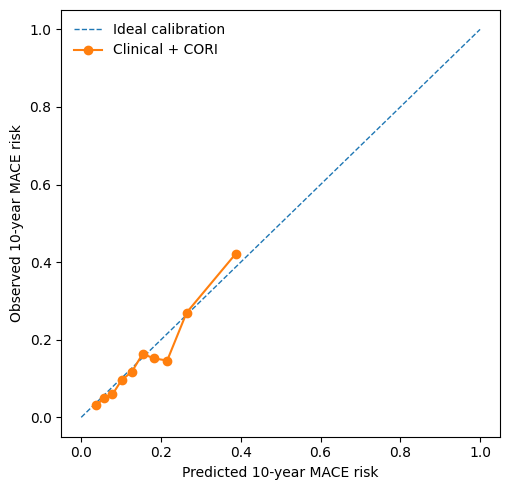

In [14]:
# 8. D1-trained clinical/CORI models and D2 calibration

MODEL_SPECS = {
    "Clinical": CLINICAL_PREDICTORS,
    "CORI": ["CORI_z"],
    "Clinical + CORI": [
        *CLINICAL_PREDICTORS,
        "CORI_z",
    ],
}

# Use one common analysis population for fair model comparison.
common_columns = [
    "time_years",
    "Y_mace",
    *CLINICAL_PREDICTORS,
    "CORI_z",
]

d1_models = d1.dropna(
    subset=common_columns
).copy()

d2_models = d2.dropna(
    subset=common_columns
).copy()

print(
    f"Model-development population: "
    f"N={len(d1_models):,}, "
    f"events={int(d1_models['Y_mace'].sum()):,}"
)

print(
    f"Held-out model population: "
    f"N={len(d2_models):,}, "
    f"events={int(d2_models['Y_mace'].sum()):,}"
)

# --------------------------------------------------------------
# Develop models in D1 and evaluate unchanged in D2
# --------------------------------------------------------------

model_rows = []
models = {}

for model_name, features in MODEL_SPECS.items():

    model, train = fit_cox(
        d1_models,
        features,
        horizon=10,
    )

    test = horizon_data(
        d2_models,
        horizon=10,
    )

    risk = (
        model.predict_partial_hazard(
            test[features]
        )
        .to_numpy()
        .ravel()
    )

    model_rows.append(
        {
            "Model": model_name,
            "Predictors": " + ".join(features),
            "D1 N": len(train),
            "D1 events": int(
                train["event_h"].sum()
            ),
            "D1 C-index": (
                model.concordance_index_
            ),
            "D2 N": len(test),
            "D2 events": int(
                test["event_h"].sum()
            ),
            "D2 C-index": concordance_index(
                test["time_h"],
                -risk,
                test["event_h"],
            ),
        }
    )

    models[model_name] = (
        model,
        features,
    )

model_performance = pd.DataFrame(
    model_rows
)

display(model_performance)

model_performance.to_csv(
    OUTPUT_DIR
    / "Table_7_clinical_CORI_combined_performance.csv",
    index=False,
)

# --------------------------------------------------------------
# Calibration of the D1-trained Clinical + CORI model in D2
# --------------------------------------------------------------

model, features = models[
    "Clinical + CORI"
]

calibration = d2_models.copy()

baseline_survival = (
    model.baseline_survival_
    .iloc[:, 0]
)

baseline_times = (
    baseline_survival.index
    .to_numpy(dtype=float)
)

position = (
    np.searchsorted(
        baseline_times,
        10.0,
        side="right",
    )
    - 1
)

survival_at_10 = (
    1.0
    if position < 0
    else float(
        baseline_survival.iloc[position]
    )
)

linear_predictor = (
    model.predict_log_partial_hazard(
        calibration[features]
    )
    .to_numpy()
    .ravel()
)

calibration[
    "predicted_10y_risk"
] = (
    1
    - survival_at_10
    ** np.exp(linear_predictor)
)

calibration[
    "linear_predictor"
] = linear_predictor

# Calibration slope in held-out D2.
slope_model, slope_data = fit_cox(
    calibration,
    ["linear_predictor"],
    horizon=10,
)

slope = slope_model.summary.loc[
    "linear_predictor"
]

# Kaplan-Meier estimate of observed 10-year risk.
km = KaplanMeierFitter()

km.fit(
    calibration["time_years"],
    calibration["Y_mace"],
)

observed_risk = (
    1
    - float(
        km.predict(10.0)
    )
)

mean_predicted_risk = (
    calibration[
        "predicted_10y_risk"
    ].mean()
)

calibration_summary = pd.DataFrame(
    [
        {
            "Model": "Clinical + CORI",
            "N": len(calibration),
            "Events": int(
                calibration["Y_mace"].sum()
            ),
            "Calibration slope": (
                slope["coef"]
            ),
            "Slope 95% CI lower": (
                slope["coef lower 95%"]
            ),
            "Slope 95% CI upper": (
                slope["coef upper 95%"]
            ),
            "Mean predicted 10-year risk": (
                mean_predicted_risk
            ),
            "Observed 10-year risk": (
                observed_risk
            ),
            "Observed minus predicted": (
                observed_risk
                - mean_predicted_risk
            ),
        }
    ]
)

# --------------------------------------------------------------
# Calibration by predicted-risk decile
# --------------------------------------------------------------

calibration["Risk decile"] = pd.qcut(
    calibration["predicted_10y_risk"],
    q=10,
    labels=False,
    duplicates="drop",
)

decile_rows = []

for decile, group in calibration.groupby(
    "Risk decile",
    observed=True,
):

    group_km = KaplanMeierFitter()

    group_km.fit(
        group["time_years"],
        group["Y_mace"],
    )

    decile_rows.append(
        {
            "Risk decile": int(decile) + 1,
            "N": len(group),
            "Events": int(
                group["Y_mace"].sum()
            ),
            "Mean predicted 10-year risk": (
                group[
                    "predicted_10y_risk"
                ].mean()
            ),
            "Observed 10-year risk": (
                1
                - float(
                    group_km.predict(10.0)
                )
            ),
        }
    )

calibration_deciles = pd.DataFrame(
    decile_rows
)

display(calibration_summary)
display(calibration_deciles)

calibration_summary.to_csv(
    OUTPUT_DIR
    / "Table_8_calibration_summary.csv",
    index=False,
)

calibration_deciles.to_csv(
    OUTPUT_DIR
    / "Table_9_calibration_deciles.csv",
    index=False,
)

# --------------------------------------------------------------
# Calibration plot
# --------------------------------------------------------------

plt.figure(figsize=(5.2, 5.0))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Ideal calibration",
)

plt.plot(
    calibration_deciles[
        "Mean predicted 10-year risk"
    ],
    calibration_deciles[
        "Observed 10-year risk"
    ],
    marker="o",
    linewidth=1.5,
    label="Clinical + CORI",
)

plt.xlabel(
    "Predicted 10-year MACE risk"
)

plt.ylabel(
    "Observed 10-year MACE risk"
)

plt.legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "Figure_calibration.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [15]:

# 9. Tertile reclassification NRI

thresholds = {
    "CORI_z": np.quantile(data.query("cohort == 'D1'")["CORI_z"], [1 / 3, 2 / 3]),
    "MMACE_equal_z": np.quantile(
        data.query("cohort == 'D3'")["MMACE_equal_z"], [1 / 3, 2 / 3]
    ),
    "MMACE_full_z": np.quantile(
        data.query("cohort == 'D3'")["MMACE_full_z"], [1 / 3, 2 / 3]
    ),
}


def nri(event, old_category, new_category):
    event = np.asarray(event)
    old_category = np.asarray(old_category)
    new_category = np.asarray(new_category)

    cases = event == 1
    controls = event == 0

    event_nri = np.mean(new_category[cases] > old_category[cases]) - np.mean(
        new_category[cases] < old_category[cases]
    )
    nonevent_nri = np.mean(
        new_category[controls] < old_category[controls]
    ) - np.mean(new_category[controls] > old_category[controls])

    return event_nri, nonevent_nri, event_nri + nonevent_nri


nri_rows = []

for comparator in ["MMACE_equal_z", "MMACE_full_z"]:
    use = horizon_data(
        d2.dropna(subset=["Y_mace", "center", comparator, "CORI_z"])
    ).reset_index(drop=True)

    old_category = np.digitize(use[comparator], thresholds[comparator])
    new_category = np.digitize(use["CORI_z"], thresholds["CORI_z"])
    point = nri(use["Y_mace"], old_category, new_category)

    boot = []

    for _ in range(N_BOOT):
        sample = use.iloc[bootstrap_positions(use)]
        boot.append(
            nri(
                sample["Y_mace"],
                np.digitize(sample[comparator], thresholds[comparator]),
                np.digitize(sample["CORI_z"], thresholds["CORI_z"]),
            )
        )

    boot = np.asarray(boot)

    for index, component in enumerate(
        ["event_NRI", "nonevent_NRI", "total_NRI"]
    ):
        nri_rows.append(
            {
                "comparison": f"CORI versus {comparator}",
                "component": component,
                "estimate": point[index],
                "CI_low": np.quantile(boot[:, index], 0.025),
                "CI_high": np.quantile(boot[:, index], 0.975),
                "p_value": bootstrap_p(boot[:, index]),
            }
        )

nri_table = pd.DataFrame(nri_rows)
display(nri_table)
nri_table.to_csv(OUTPUT_DIR / "Table_10_tertile_NRI.csv", index=False)


,comparison,component,estimate,CI_low,CI_high,p_value
0,CORI versus MMACE_equal_z,event_NRI,-0.055215,-0.110429,-0.006135,0.033966
1,CORI versus MMACE_equal_z,nonevent_NRI,0.099324,0.077483,0.121178,0.001998
2,CORI versus MMACE_equal_z,total_NRI,0.044109,-0.015015,0.099845,0.143856
3,CORI versus MMACE_full_z,event_NRI,-0.030675,-0.085890,0.027607,0.307692
4,CORI versus MMACE_full_z,nonevent_NRI,0.041082,0.014041,0.065523,0.001998
5,CORI versus MMACE_full_z,total_NRI,0.010407,-0.053460,0.067030,0.741259


In [16]:

# 10. Residual CORI and cancer-by-score interactions

residual_rows = []

for comparator, label in [
    ("MMACE_equal_z", "Residual CORI beyond equal MMACE"),
    ("MMACE_full_z", "Residual CORI beyond full MMACE"),
]:
    train = data.query("cohort == 'D1'").dropna(subset=["CORI_z", comparator])

    regression = LinearRegression().fit(
        train[[comparator]], train["CORI_z"]
    )

    column = f"residual_{comparator}"
    data[column] = data["CORI_z"] - regression.predict(data[[comparator]])

    d1_mean = data.query("cohort == 'D1'")[column].mean()
    d1_sd = data.query("cohort == 'D1'")[column].std(ddof=1)
    data[column] = (data[column] - d1_mean) / d1_sd

    validation = data.query("cohort == 'D2'")
    model, use = fit_cox(validation, [column, *ADJUST])

    common = validation.dropna(
        subset=["time_years", "Y_mace", comparator, column, *ADJUST]
    )
    reduced, _ = fit_cox(common, [comparator, *ADJUST])
    full, _ = fit_cox(
        common, [comparator, column, *ADJUST]
    )
    lr = 2 * (full.log_likelihood_ - reduced.log_likelihood_)

    residual_rows.append(
        {
            "residual": label,
            "D1_R_squared": regression.score(
                train[[comparator]], train["CORI_z"]
            ),
            "D2_C_index": cindex(validation, column),
            **hr_row(model, column),
            "incremental_LR_chi2": lr,
            "incremental_p": stats.chi2.sf(lr, 1),
        }
    )

residual_table = pd.DataFrame(residual_rows)
display(residual_table)
residual_table.to_csv(
    OUTPUT_DIR / "Table_11_residual_CORI.csv", index=False
)

pathway = data.query("cohort in ['D2', 'D4']").copy()
pathway["A_cancer"] = pathway["cohort"].eq("D2").astype(int)

interaction_scores = [
    ("CORI", "CORI_z"),
    ("Equal MMACE", "MMACE_equal_z"),
    ("Full MMACE", "MMACE_full_z"),
    ("Residual CORI beyond equal MMACE", "residual_MMACE_equal_z"),
    ("Residual CORI beyond full MMACE", "residual_MMACE_full_z"),
]

interaction_rows = []

for label, score in interaction_scores:
    use = pathway.dropna(
        subset=["time_years", "Y_mace", "A_cancer", score, *ADJUST]
    ).copy()
    use["interaction"] = use["A_cancer"] * use[score]

    model, fitted_data = fit_cox(
        use,
        ["A_cancer", score, "interaction", *ADJUST],
        
    )

    interaction_rows.append(
        {
            "score": label,
            "N": len(fitted_data),
            "events": int(fitted_data["event_h"].sum()),
            "HR_score_never_cancer": np.exp(model.params_[score]),
            "HR_cancer_by_score_interaction": np.exp(
                model.params_["interaction"]
            ),
            "interaction_CI_low": np.exp(
                model.summary.loc["interaction", "coef lower 95%"]
            ),
            "interaction_CI_high": np.exp(
                model.summary.loc["interaction", "coef upper 95%"]
            ),
            "interaction_p": model.summary.loc["interaction", "p"],
        }
    )

interaction_table = pd.DataFrame(interaction_rows)
interaction_table["interaction_q"] = bh(interaction_table["interaction_p"])

display(interaction_table)
interaction_table.to_csv(
    OUTPUT_DIR / "Table_12_cancer_score_interactions.csv", index=False
)


,residual,D1_R_squared,D2_C_index,HR,CI_low,CI_high,p_value,incremental_LR_chi2,incremental_p
0,Residual CORI beyond equal MMACE,0.686914,0.549168,1.160793,1.015287,1.327152,0.029111,4.948568,0.026112
1,Residual CORI beyond full MMACE,0.573000,0.524080,1.098660,0.966741,1.248580,0.149390,1.909613,0.167006


,score,N,events,HR_score_never_cancer,HR_cancer_by_score_interaction,interaction_CI_low,interaction_CI_high,interaction_p,interaction_q
0,CORI,17012,1787,1.055847,1.188144,1.043527,1.352803,0.009231,0.026652
1,Equal MMACE,17012,1787,1.055465,1.131158,0.995066,1.285862,0.059518,0.074398
2,Full MMACE,17012,1787,1.053640,1.189799,1.041228,1.359569,0.010661,0.026652
3,Residual CORI beyond equal MMACE,17012,1787,1.007457,1.166691,1.009222,1.348729,0.037156,0.061926
4,Residual CORI beyond full MMACE,17012,1787,1.026577,1.079137,0.939607,1.239388,0.280971,0.280971


In [17]:

# 11. Import completed four-way decomposition and save the output manifest

fourway_files = {
    "primary": FOURWAY_DIR / "Table_02_fourway_primary_ipcw_logistic.csv",
    "paths": FOURWAY_DIR / "Table_03_fourway_primary_path_diagnostics.csv",
    "CORI summary": FOURWAY_DIR / "Table_04_CORI_fourway_manuscript_summary.csv",
}

for label, path in fourway_files.items():
    if path.exists():
        table = pd.read_csv(path)
        display(table)
        table.to_csv(
            OUTPUT_DIR / f"Table_13_fourway_{label.replace(' ', '_')}.csv",
            index=False,
        )
    else:
        print("Missing four-way output:", path)

manifest = pd.DataFrame(
    [
        {
            "file": path.name,
            "path": str(path),
        }
        for path in sorted(OUTPUT_DIR.glob("*.csv"))
    ]
)

manifest.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)
display(manifest)

run_info = {
    "score_representation": "meanpool_pre",
    "representations_checked": ["cls", "meanpool_norm", "meanpool_pre"],
    "bootstrap_repetitions": N_BOOT,
    "adjustment_covariates": ADJUST,
    "cohort_counts": locked_check.to_dict("records"),
}

with open(OUTPUT_DIR / "run_info.json", "w") as file:
    json.dump(run_info, file, indent=2)

print("Complete:", OUTPUT_DIR)


Missing four-way output: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\four_way_decomposition\tables\Table_02_fourway_primary_ipcw_logistic.csv
Missing four-way output: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\four_way_decomposition\tables\Table_03_fourway_primary_path_diagnostics.csv
Missing four-way output: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\four_way_decomposition\tables\Table_04_CORI_fourway_manuscript_summary.csv


,file,path
0,Table_10_tertile_NRI.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
1,Table_11_residual_CORI.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
2,Table_12_cancer_score_interactions.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
3,Table_1_D1_D2_baseline.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
4,Table_2_score_performance.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
5,Table_3_D2_Cindex_bootstrap_CI.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
6,Table_4_D2_paired_Cindex_comparisons.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
7,Table_5_adjusted_score_associations.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
8,Table_6_incremental_tests.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...
9,Table_7_clinical_CORI_combined_performance.csv,F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outp...


Complete: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\additional_manuscript_analyses


D2 participants without subtype information: 7


,eid
99,1286536
486,2024162
531,2098075
595,2222802
737,2512842
878,2790417
1486,4074949


Adjustment covariates: ['age', 'female', 'Diabetes', 'HTN']


f:\CORI_Final\.venv\Lib\site-packages\lifelines\utils\__init__.py:1120: ConvergenceWarning: Column Diabetes have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event_h'].astype(bool)
>>> print(df.loc[events, 'Diabetes'].var())
>>> print(df.loc[~events, 'Diabetes'].var())

A very low variance means that the column Diabetes completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
f:\CORI_Final\.venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.638. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in

,cancer_type,N,events,event_rate_percent,CORI_C_index,CORI_HR_per_SD,CORI_CI_low,CORI_CI_high,CORI_p,interaction_HR,interaction_CI_low,interaction_CI_high,interaction_p,status,CORI_q,interaction_q
0,Female reproductive,75,17,22.666667,0.516760,0.658665,0.335460,1.293267,0.225164,0.562294,0.318927,0.991369,0.046599,estimated,0.385996,0.440475
1,Breast,344,45,13.081395,0.668977,1.619599,1.114162,2.354327,0.011525,1.384820,0.969609,1.977834,0.073412,estimated,0.138300,0.440475
2,Secondary/metastatic,256,50,19.531250,0.600886,1.435917,0.995433,2.071319,0.052932,0.861824,0.620557,1.196892,0.374856,estimated,0.232946,0.845957
3,All cancer,2249,326,14.495331,0.639317,1.227973,1.074090,1.403901,0.002645,NaN,NaN,NaN,NaN,estimated,NaN,NaN
4,Skin,357,69,19.327731,0.619437,1.333429,0.990015,1.795965,0.058236,1.031628,0.766180,1.389043,0.837448,estimated,0.232946,0.895131
5,Respiratory,64,19,29.687500,0.616240,1.010446,0.532860,1.916077,0.974608,0.961735,0.538400,1.717931,0.895131,estimated,0.984691,0.895131
6,In situ,157,21,13.375796,0.665555,1.430456,0.913852,2.239098,0.117369,1.145967,0.717571,1.830119,0.568378,estimated,0.300428,0.895131
7,Hematologic,104,26,25.000000,0.623866,1.004469,0.636994,1.583937,0.984691,0.931572,0.617192,1.406088,0.735777,estimated,0.984691,0.895131
8,Lip/oral,27,5,18.518519,0.634783,1.297447,0.307877,5.467660,0.722735,0.707613,0.317758,1.575783,0.397168,exploratory: <10 events,0.963646,0.845957
9,Male reproductive,156,39,25.000000,0.629414,1.346063,0.920653,1.968046,0.125178,1.174102,0.792866,1.738648,0.422978,estimated,0.300428,0.845957


,cancer_type,term,wald_chi2,relative_wald_percent
0,Female reproductive,CORI_z,1.471150,26.686100
1,Female reproductive,age,3.618749,65.642709
2,Female reproductive,Diabetes,0.106880,1.938760
3,Female reproductive,HTN,0.316017,5.732431
4,Breast,CORI_z,6.382517,56.369321
...,...,...,...,...
58,Digestive,CORI_z,1.247964,8.878090
59,Digestive,age,0.162990,1.159520
60,Digestive,female,0.012093,0.086034
61,Digestive,Diabetes,0.037574,0.267306


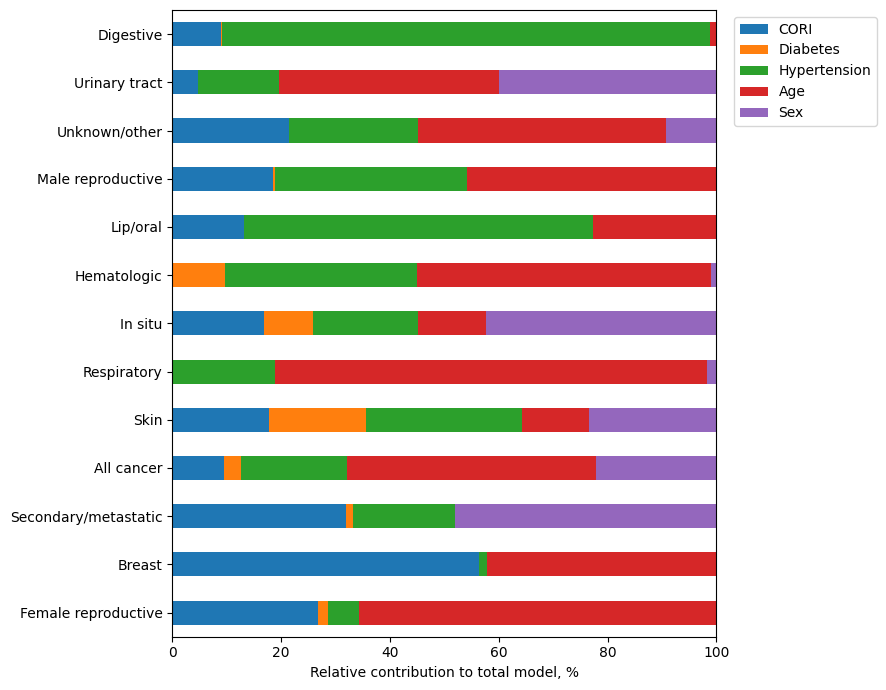

In [18]:
# Main cancer-type subgroup analysis in held-out D2

SUBTYPE_CSV = (
    ROOT
    / "data"
    / "CORI_allcancer_8Jan2026.csv"
)

MIN_N = 20
MIN_EVENTS = 5

MAIN_TYPES = {
    "Female reproductive": "FemRepoCancer_present",
    "Breast": "BreastCancer_present",
    "Secondary/metastatic": "SecondaryCancer_present",
    "All cancer": None,
    "Skin": "SkinCancer_present",
    "Respiratory": "RespiCancer_present",
    "In situ": "InsituCancer_present",
    "Hematologic": "HeamatoCancer_present",
    "Lip/oral": "LipOralCancer_present",
    "Male reproductive": "MaleRepoCancer_present",
    "Unknown/other": "UnknownCancer_present",
    "Urinary tract": "UrinaryTractCancer_present",
    "Digestive": "DigestiveCancer_present",
}


def binary_column(series):
    """Convert numeric, Boolean, or Yes/No subtype fields to 0/1."""
    numeric = pd.to_numeric(series, errors="coerce")

    text = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": 1,
                "false": 0,
                "yes": 1,
                "no": 0,
                "present": 1,
                "absent": 0,
            }
        )
    )

    return numeric.fillna(text)


# ------------------------------------------------------------------
# Load subtype labels
# ------------------------------------------------------------------

subtypes = pd.read_csv(SUBTYPE_CSV)

eid_col = next(
    column
    for column in ["eid", "EID", "participant_id"]
    if column in subtypes.columns
)

subtypes = subtypes.rename(
    columns={eid_col: "eid"}
)

subtypes["eid"] = normalize_eid(
    subtypes["eid"]
)

subtype_columns = [
    column
    for column in MAIN_TYPES.values()
    if column is not None
]

missing_columns = [
    column
    for column in subtype_columns
    if column not in subtypes.columns
]

if missing_columns:
    raise KeyError(
        f"Missing subtype columns: {missing_columns}"
    )

subtypes = (
    subtypes[
        ["eid", *subtype_columns]
    ]
    .drop_duplicates("eid")
)

for column in subtype_columns:
    subtypes[column] = binary_column(
        subtypes[column]
    )

# ------------------------------------------------------------------
# Merge with D2
# ------------------------------------------------------------------

d2_subtypes = (
    data.query("cohort == 'D2'")
    .merge(
        subtypes,
        on="eid",
        how="left",
        validate="one_to_one",
        indicator=True,
    )
)

unmatched = d2_subtypes.loc[
    d2_subtypes["_merge"] == "left_only",
    ["eid"],
].copy()

print(
    f"D2 participants without subtype information: "
    f"{len(unmatched)}"
)

if len(unmatched):
    display(unmatched)

    unmatched.to_csv(
        OUTPUT_DIR
        / "D2_participants_missing_cancer_subtype.csv",
        index=False,
    )

# Do not convert missing subtype values to zero.
# They remain in "All cancer" but are excluded from subtype interactions.
d2_subtypes = d2_subtypes.drop(
    columns="_merge"
)

covariates = [
    column
    for column in [
        "age",
        "female",
        "Diabetes",
        "HTN",
    ]
    if column in d2_subtypes.columns
]

print("Adjustment covariates:", covariates)

# ------------------------------------------------------------------
# Subgroup Cox and interaction models
# ------------------------------------------------------------------

results = []
wald_results = []

for cancer_type, subtype_column in MAIN_TYPES.items():

    subgroup = (
        d2_subtypes.copy()
        if subtype_column is None
        else d2_subtypes[
            d2_subtypes[subtype_column] == 1
        ].copy()
    )

    n = len(subgroup)
    events = int(
        subgroup["Y_mace"].sum()
    )

    result = {
        "cancer_type": cancer_type,
        "N": n,
        "events": events,
        "event_rate_percent": (
            100 * events / n
            if n
            else np.nan
        ),
        "CORI_C_index": np.nan,
        "CORI_HR_per_SD": np.nan,
        "CORI_CI_low": np.nan,
        "CORI_CI_high": np.nan,
        "CORI_p": np.nan,
        "interaction_HR": np.nan,
        "interaction_CI_low": np.nan,
        "interaction_CI_high": np.nan,
        "interaction_p": np.nan,
        "status": "not estimated",
    }

    if (
        n < MIN_N
        or events < MIN_EVENTS
        or n - events < MIN_EVENTS
    ):
        result["status"] = "insufficient events"
        results.append(result)
        continue

    try:
        # Remove covariates that are constant within the subgroup.
        subgroup_covariates = [
            column
            for column in covariates
            if subgroup[column].nunique(
                dropna=True
            ) > 1
        ]

        strata = None

        model, used = fit_cox(
            subgroup,
            ["CORI_z", *subgroup_covariates],
            horizon=10,
            
        )

        row = model.summary.loc["CORI_z"]

        result.update(
            {
                "CORI_C_index": cindex(
                    subgroup,
                    "CORI_z",
                    horizon=10,
                ),
                "CORI_HR_per_SD": np.exp(
                    row["coef"]
                ),
                "CORI_CI_low": np.exp(
                    row["coef lower 95%"]
                ),
                "CORI_CI_high": np.exp(
                    row["coef upper 95%"]
                ),
                "CORI_p": row["p"],
                "status": (
                    "exploratory: <10 events"
                    if events < 10
                    else "estimated"
                ),
            }
        )

        # Relative Wald contribution used in the manuscript figure.
        terms = [
            "CORI_z",
            *subgroup_covariates,
        ]

        wald = {
            term: model.summary.loc[
                term,
                "z",
            ] ** 2
            for term in terms
        }

        total_wald = sum(
            wald.values()
        )

        for term, value in wald.items():
            wald_results.append(
                {
                    "cancer_type": cancer_type,
                    "term": term,
                    "wald_chi2": value,
                    "relative_wald_percent": (
                        100 * value / total_wald
                        if total_wald > 0
                        else np.nan
                    ),
                }
            )

        # Formal CORI × subtype interaction.
        if subtype_column is not None:

            interaction_data = d2_subtypes.dropna(
                subset=[
                    subtype_column,
                    "CORI_z",
                    "time_years",
                    "Y_mace",
                    *covariates,
                ]
            ).copy()

            interaction_data[
                "CORI_x_subtype"
            ] = (
                interaction_data["CORI_z"]
                * interaction_data[subtype_column]
            )

            interaction_model, _ = fit_cox(
                interaction_data,
                [
                    "CORI_z",
                    subtype_column,
                    "CORI_x_subtype",
                    *covariates,
                ],
                horizon=10,
                
            )

            interaction_row = (
                interaction_model.summary.loc[
                    "CORI_x_subtype"
                ]
            )

            result.update(
                {
                    "interaction_HR": np.exp(
                        interaction_row["coef"]
                    ),
                    "interaction_CI_low": np.exp(
                        interaction_row[
                            "coef lower 95%"
                        ]
                    ),
                    "interaction_CI_high": np.exp(
                        interaction_row[
                            "coef upper 95%"
                        ]
                    ),
                    "interaction_p": interaction_row[
                        "p"
                    ],
                }
            )

    except Exception as error:
        result["status"] = (
            f"model failed: {error}"
        )

    results.append(result)

# ------------------------------------------------------------------
# FDR correction and save
# ------------------------------------------------------------------

subgroup_results = pd.DataFrame(
    results
)

subgroup_results["CORI_q"] = np.nan
subgroup_results["interaction_q"] = np.nan

subtype_rows = (
    subgroup_results["cancer_type"]
    != "All cancer"
)

valid_cori = (
    subtype_rows
    & subgroup_results["CORI_p"].notna()
)

valid_interaction = (
    subtype_rows
    & subgroup_results["interaction_p"].notna()
)

if valid_cori.any():
    subgroup_results.loc[
        valid_cori,
        "CORI_q",
    ] = bh(
        subgroup_results.loc[
            valid_cori,
            "CORI_p",
        ]
    )

if valid_interaction.any():
    subgroup_results.loc[
        valid_interaction,
        "interaction_q",
    ] = bh(
        subgroup_results.loc[
            valid_interaction,
            "interaction_p",
        ]
    )

order = list(
    MAIN_TYPES.keys()
)

subgroup_results[
    "cancer_type"
] = pd.Categorical(
    subgroup_results["cancer_type"],
    categories=order,
    ordered=True,
)

subgroup_results = (
    subgroup_results
    .sort_values("cancer_type")
    .reset_index(drop=True)
)

wald_results = pd.DataFrame(
    wald_results
)

display(subgroup_results)
display(wald_results)

subgroup_results.to_csv(
    OUTPUT_DIR
    / "Table_14_CORI_main_cancer_subtypes_D2.csv",
    index=False,
)

wald_results.to_csv(
    OUTPUT_DIR
    / "Table_15_CORI_subtype_Wald_contributions.csv",
    index=False,
)

# ------------------------------------------------------------------
# Relative Wald contribution plot
# ------------------------------------------------------------------

if not wald_results.empty:

    plot_data = (
        wald_results.pivot(
            index="cancer_type",
            columns="term",
            values="relative_wald_percent",
        )
        .fillna(0)
        .reindex(order)
        .rename(
            columns={
                "CORI_z": "CORI",
                "age": "Age",
                "female": "Sex",
                "height": "Height",
                "Diabetes": "Diabetes",
                "HTN": "Hypertension",
            }
        )
    )

    axis = plot_data.plot(
        kind="barh",
        stacked=True,
        figsize=(9, 7),
    )

    axis.set_xlabel(
        "Relative contribution to total model, %"
    )
    axis.set_ylabel("")
    axis.set_xlim(0, 100)

    axis.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "Figure_CORI_cancer_subtype_Wald_contributions.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()